# **Notebook 2c: Evaluation of model 1 (feature based)**

Evaluates the features based sentence classifier (baseline) on the test set.

## 1. Importing packages

In [16]:
import os
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## 2. Preparation

In [43]:
MODEL_DIR      = "./Model 2: Feature based/model_2"
TEST_DATA_PATH = "./Model 1: Finetuning with handlabeled data/labeled_test.csv"
FEATURES_TEST  = "./Model 2: Feature based/Data_with_features/features_test.csv"
THRESHOLD_PATH = "./Model 2: Feature based/model_2/lr2_threshold.json"
LABEL_COL      = "unnecessary"
ID_COLS = ["blurb_id", "blurb_sent"]
EXCLUDE = ID_COLS + [LABEL_COL]

## 3. Loading data and model

In [44]:
# Loading test dataset
test_df = pd.read_csv(TEST_DATA_PATH)
print(f"Test: {len(test_df)} sentences, {test_df[LABEL_COL].mean():.1%} positive")

Test: 481 sentences, 23.1% positive


In [45]:
# Loading model
lr2_model  = joblib.load(os.path.join(MODEL_DIR, "lr2_classification_model.joblib"))
lr2_scaler = joblib.load(os.path.join(MODEL_DIR, "lr2_scaler.joblib"))
with open(os.path.join(MODEL_DIR, "lr2_feature_cols.json")) as f:
    feature_cols = json.load(f)
print("Model loaded")

Model loaded


## 4. Generating test predictions

In [46]:
# Generate probabilities
test_features = pd.read_csv(FEATURES_TEST)
X_test = test_features[feature_cols].copy()
test_probs  = lr2_model.predict_proba(lr2_scaler.transform(X_test))[:, 1]
test_labels = test_features[LABEL_COL].astype(int).values
print(f"Generated predictions for {len(test_probs)} sentences")

Generated predictions for 481 sentences


In [47]:
# Loading threshold and translating probabilities into predictions
with open(THRESHOLD_PATH) as f:
    CHOSEN_THRESHOLD = json.load(f)["threshold"]
print(f"Threshold: {CHOSEN_THRESHOLD}")

test_preds = (test_probs >= CHOSEN_THRESHOLD).astype(int)

Threshold: 0.6200000000000001


In [49]:
# Save predictions
np.save("./Model 2: Feature based/model_2/test_probs.npy", test_probs)
np.save("./Model 2: Feature based/model_2/test_labels.npy", test_labels)

## 5. Evaluation

In [50]:
# Metrics
print(classification_report(test_labels, test_preds,
    target_names=["necessary (0)", "unnecessary (1)"], digits=3))
print(f"Macro F1 : {f1_score(test_labels, test_preds, average='macro'):.3f}")
print(f"AUC      : {roc_auc_score(test_labels, test_probs):.3f}")

                 precision    recall  f1-score   support

  necessary (0)      0.851     0.895     0.872       370
unnecessary (1)      0.576     0.477     0.522       111

       accuracy                          0.798       481
      macro avg      0.713     0.686     0.697       481
   weighted avg      0.787     0.798     0.791       481

Macro F1 : 0.697
AUC      : 0.783


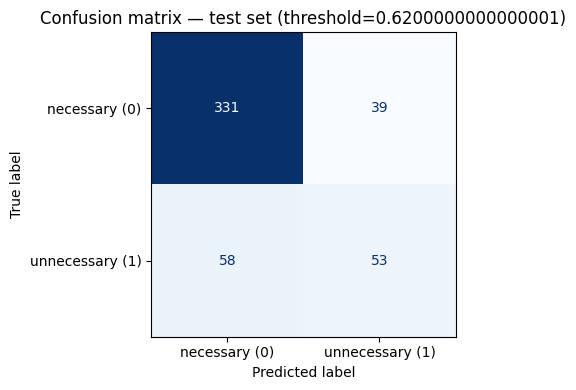

In [52]:
# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm,
    display_labels=["necessary (0)", "unnecessary (1)"]).plot(
    ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion matrix — test set (threshold={CHOSEN_THRESHOLD})")
plt.tight_layout()
plt.show()

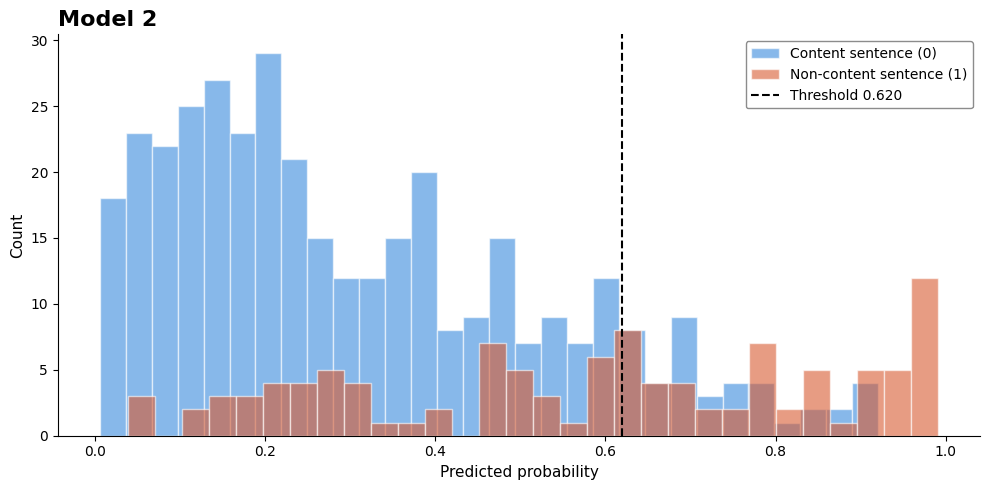

In [53]:
# Probability distribution
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(test_probs[test_labels == 0], bins=30, alpha=0.6, label="Content sentence (0)",
        color="#378ADD", edgecolor="white")
ax.hist(test_probs[test_labels == 1], bins=30, alpha=0.6, label="Non-content sentence (1)",
        color="#D85A30", edgecolor="white")
ax.axvline(CHOSEN_THRESHOLD, linestyle="--", color="black", linewidth=1.5, label=f"Threshold {CHOSEN_THRESHOLD:.3f}")

ax.set_xlabel("Predicted probability", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Model 2", fontsize=16, fontweight="bold", loc="left")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(True)
ax.spines["bottom"].set_color("black")

ax.legend(frameon=True, fontsize=10, loc="upper right", facecolor="white", edgecolor="gray", framealpha=0.9)

plt.tight_layout()
plt.show()